# Tidal Energy Assignment
**OE44170 – Offshore Renewable Technologies 2026**

- **Part 1 – Tidal stream**
  - 1a: Environmental data and tidal resource (20 pts)
  - 1b: Tidal stream energy production (25 pts)
- **Part 2 – Operation of a tidal range power plant** (55 pts)

Run the cells from top to bottom (*Run All*). Figures are shown inline and also saved in `output/`. Part 2 reads `data/Tidal_range_Dataset_2026.csv`.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "axes.grid": True,
                     "grid.alpha": 0.3})

# Colours
C_U, C_ENV, C_SP, C_NP, C_REF = "#2a78d6", "#52514e", "#eb6834", "#1baf7a", "#8a8984"

---
# Part 1 – Tidal Stream

**Site:** Group 21. Appendix 1 only lists groups 1–20, so this wraps around to row 1: **SN167BV** (47°33.7'N, 02°54.9'W).

## 1.1 Input data

### Site data (Appendix 1, row 1)
| Adm. Ref | Lat | Long | Pk Sp [kt] | Pk Np [kt] | F | M2 [m/s] | S2 [m/s] | K2 [m/s] |
|---|---|---|---|---|---|---|---|---|
| SN167BV | 47 33.7N | 02 54.9W | 5.2 | 3.5 | 0 | 2.2185 | 0.4335 | 0.4437 |

The constituent periods come from the pre-assignment lecture: $T_{M2} = 12.4206$ h, $T_{S2} = 12.0$ h, $T_{K2} = 11.965$ h.

### Turbine data (Part 1b)
| Cut-in | Cut-out | Rated power | Efficiency | Capture area | $\rho_{water}$ |
|---|---|---|---|---|---|
| 1.0 m/s | 3.0 m/s | 1.0 MW | 0.45 | 165 m² | 1025 kg/m³ |

In [2]:
# ---- Site ----
ADM_REF = "SN167BV"
PK_SP_KT, PK_NP_KT = 5.2, 3.5   # peak spring / neap current [kt]
FZU = 0.0                       # Formzahl number
KNOT = 0.514444                 # m/s per knot

# Constituents: name -> (amplitude [m/s], period [h])
CONSTITUENTS = {
    "M2": (2.2185, 12.4206),
    "S2": (0.4335, 12.0),
    "K2": (0.4437, 11.965),
}

# ---- Turbine ----
U_CUT_IN = 1.0      # m/s
U_CUT_OUT = 3.0     # m/s
P_RATED = 1.0e6     # W
ETA = 0.45          # water-to-wire efficiency
A_CAPTURE = 165.0   # m2
RHO = 1025.0        # kg/m3

# ---- Time ----
N_HOURS = 365 * 24
DT = 1.0            # h

print(f"Peak spring current: {PK_SP_KT} kt = {PK_SP_KT * KNOT:.3f} m/s")
print(f"Peak neap current  : {PK_NP_KT} kt = {PK_NP_KT * KNOT:.3f} m/s")

Peak spring current: 5.2 kt = 2.675 m/s
Peak neap current  : 3.5 kt = 1.801 m/s


---
## 1.2 Part 1a – Tidal resource by harmonic superposition

The current velocity is written as a sum of harmonic constituents:

$$U(t) = \sum_{i=1}^{n} U_{A,i}\cos\left(\frac{2\pi t}{T_{A,i}} + \varphi_{A,i}\right)$$

- The Formzahl number is $F = 0$, so the tide is **purely semi-diurnal**. The diurnal constituents (K1, O1) can be neglected, and only M2, S2 and K2 are superposed.
- All phases are set to $\varphi_{A,i} = 0$, so $t = 0$ is a spring tide with all constituents in phase. The phases only shift the series in time; they do not change the annual statistics.
- Positive $U$ is flood and negative $U$ is ebb.

In [3]:
t = np.arange(N_HOURS) * DT          # h, 0 ... 8759
U = np.zeros_like(t)
for amp, per in CONSTITUENTS.values():
    U += amp * np.cos(2 * np.pi * t / per)

speed = np.abs(U)
print(f"Generated {len(U)} hourly values ({len(U) / 24:.0f} days)")

Generated 8760 hourly values (365 days)


### Checking the model against the tabulated spring and neap currents

The **spring–neap period** is the beat between M2 and S2:

$$T_{sn} = \left(\frac{1}{T_{S2}} - \frac{1}{T_{M2}}\right)^{-1}$$

K2 has almost the same period as S2, so it beats slowly against S2 (about half a year). This makes the spring tides stronger around the equinoxes.

In [4]:
T_M2, T_S2, T_K2 = (CONSTITUENTS[k][1] for k in ("M2", "S2", "K2"))
A_M2, A_S2, A_K2 = (CONSTITUENTS[k][0] for k in ("M2", "S2", "K2"))

T_sn = 1 / (1 / T_S2 - 1 / T_M2)     # spring-neap period [h]
T_S2K2 = 1 / (1 / T_K2 - 1 / T_S2)   # S2-K2 beat period [h]

daily_max = speed.reshape(365, 24).max(axis=1)

print(f"Spring-neap period (M2-S2 beat) : {T_sn:.1f} h = {T_sn / 24:.2f} days")
print(f"S2-K2 beat period               : {T_S2K2:.0f} h = {T_S2K2 / 24:.1f} days")
print()
print(f"M2 + S2      = {A_M2 + A_S2:.3f} m/s   vs tabulated peak spring {PK_SP_KT * KNOT:.3f} m/s")
print(f"M2 - S2      = {A_M2 - A_S2:.3f} m/s   vs tabulated peak neap   {PK_NP_KT * KNOT:.3f} m/s")
print(f"M2 + S2 + K2 = {A_M2 + A_S2 + A_K2:.3f} m/s   (theoretical maximum)")
print(f"M2 - S2 - K2 = {A_M2 - A_S2 - A_K2:.3f} m/s   (theoretical minimum neap)")
print()
print(f"Max |U| in hourly series        : {speed.max():.3f} m/s")
print(f"Smallest daily max (neap)       : {daily_max.min():.3f} m/s")
print(f"Mean |U| over the year          : {speed.mean():.3f} m/s")
print(f"RMS U over the year             : {np.sqrt(np.mean(U**2)):.3f} m/s")
print(f"Hours with |U| > cut-out 3 m/s  : {np.sum(speed > U_CUT_OUT)} h")

Spring-neap period (M2-S2 beat) : 354.4 h = 14.77 days
S2-K2 beat period               : 4102 h = 170.9 days

M2 + S2      = 2.652 m/s   vs tabulated peak spring 2.675 m/s
M2 - S2      = 1.785 m/s   vs tabulated peak neap   1.801 m/s
M2 + S2 + K2 = 3.096 m/s   (theoretical maximum)
M2 - S2 - K2 = 1.341 m/s   (theoretical minimum neap)

Max |U| in hourly series        : 3.096 m/s
Smallest daily max (neap)       : 1.369 m/s
Mean |U| over the year          : 1.439 m/s
RMS U over the year             : 1.629 m/s
Hours with |U| > cut-out 3 m/s  : 47 h


### Plot: current velocity over 30 days

The dashed envelope connects the flood and ebb peaks. Spring tides are marked every $T_{sn}$, and neap tides halfway between them.

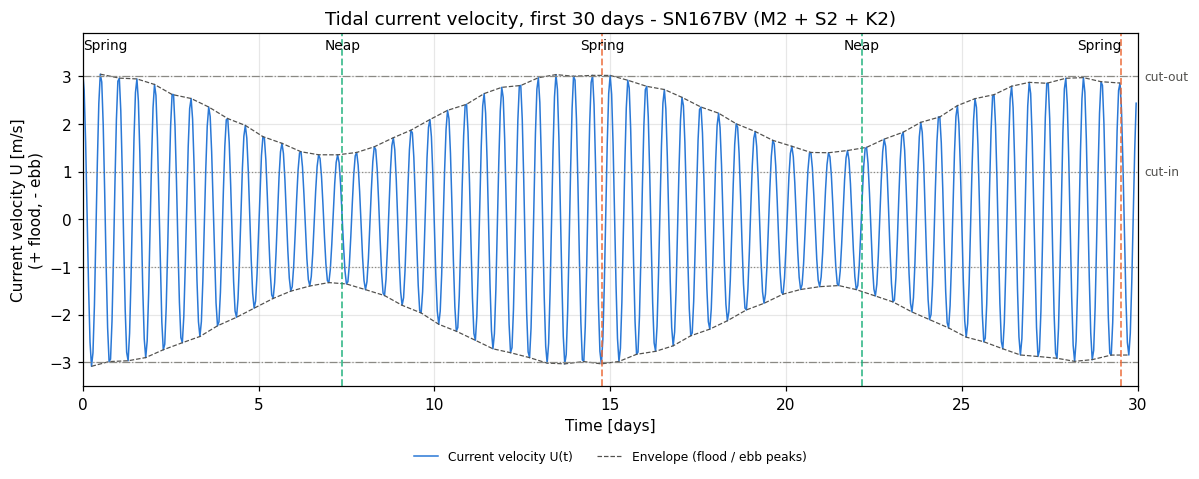

In [5]:
n30 = 30 * 24

# Local peaks of |U| -> envelope
is_peak = (speed[1:-1] >= speed[:-2]) & (speed[1:-1] > speed[2:])
peak_idx = np.where(is_peak)[0] + 1
pk30 = peak_idx[peak_idx < n30]
pos, neg = pk30[U[pk30] > 0], pk30[U[pk30] < 0]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t[:n30] / 24, U[:n30], color=C_U, lw=1.0, label="Current velocity U(t)")
ax.plot(t[pos] / 24, U[pos], color=C_ENV, lw=0.8, ls="--", label="Envelope (flood / ebb peaks)")
ax.plot(t[neg] / 24, U[neg], color=C_ENV, lw=0.8, ls="--")
for u in (U_CUT_IN, -U_CUT_IN):
    ax.axhline(u, color=C_REF, lw=0.8, ls=":")
for u in (U_CUT_OUT, -U_CUT_OUT):
    ax.axhline(u, color=C_REF, lw=0.8, ls="-.")
ax.text(30.2, U_CUT_IN, "cut-in", va="center", fontsize=8, color=C_ENV)
ax.text(30.2, U_CUT_OUT, "cut-out", va="center", fontsize=8, color=C_ENV)

# Spring every T_sn, neap halfway in between
for k in range(5):
    tk = k * T_sn / 48   # days
    if tk > 30:
        break
    spring = k % 2 == 0
    ax.axvline(tk, color=C_SP if spring else C_NP, lw=1.2, ls="--", alpha=0.8)
    ax.text(tk, 3.5, "Spring" if spring else "Neap", fontsize=9, va="bottom",
            ha="left" if tk < 1 else ("right" if tk > 29 else "center"))

ax.set_xlim(0, 30)
ax.set_ylim(-3.5, 3.9)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Current velocity U [m/s]\n(+ flood, - ebb)")
ax.set_title(f"Tidal current velocity, first 30 days - {ADM_REF} (M2 + S2 + K2)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/tidal_velocity_30days.png")
plt.show()

### Supporting plot: daily maximum speed over the whole year

This shows the spring–neap modulation through the year. The strongest springs, at the start and around 6 months, are where S2 and K2 are in phase; their peaks go above the 3.0 m/s cut-out.

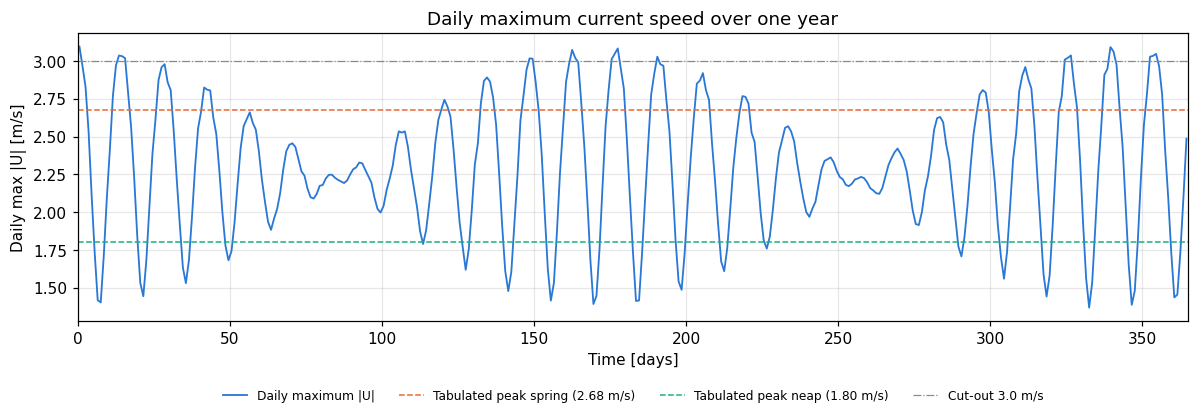

In [6]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(365) + 0.5, daily_max, color=C_U, lw=1.2, label="Daily maximum |U|")
ax.axhline(PK_SP_KT * KNOT, color=C_SP, lw=1, ls="--", label=f"Tabulated peak spring ({PK_SP_KT * KNOT:.2f} m/s)")
ax.axhline(PK_NP_KT * KNOT, color=C_NP, lw=1, ls="--", label=f"Tabulated peak neap ({PK_NP_KT * KNOT:.2f} m/s)")
ax.axhline(U_CUT_OUT, color=C_REF, lw=0.8, ls="-.", label="Cut-out 3.0 m/s")
ax.set_xlim(0, 365)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Daily max |U| [m/s]")
ax.set_title("Daily maximum current speed over one year")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/tidal_velocity_daily_max_year.png")
plt.show()

---
## 1.3 Part 1b – Tidal stream energy production

The turbine is **bi-directional**, so it produces the same power on flood and ebb and only $|U|$ matters. Electrical power:

$$
P(U) =
\begin{cases}
0 & |U| < U_{cut\text{-}in} \\
\min\left(\tfrac{1}{2}\rho A \eta |U|^3,\; P_{rated}\right) & U_{cut\text{-}in} \le |U| \le U_{cut\text{-}out} \\
0 & |U| > U_{cut\text{-}out}
\end{cases}
$$

The rated speed follows from $\tfrac{1}{2}\rho A \eta U_r^3 = P_{rated}$.

In [7]:
def turbine_power(u):
    # Electrical power [W] of the bi-directional turbine for velocity u [m/s]
    s = np.abs(u)
    p = 0.5 * RHO * A_CAPTURE * ETA * s**3
    p = np.minimum(p, P_RATED)
    p[(s < U_CUT_IN) | (s > U_CUT_OUT)] = 0.0
    return p


U_rated = (P_RATED / (0.5 * RHO * A_CAPTURE * ETA)) ** (1 / 3)
P = turbine_power(U)

print(f"Rated speed U_r   : {U_rated:.3f} m/s")
print(f"Power at cut-in   : {turbine_power(np.array([U_CUT_IN]))[0] / 1e3:.1f} kW")

Rated speed U_r   : 2.973 m/s
Power at cut-in   : 38.1 kW


Rated power is reached at about 2.97 m/s, only just below the 3.0 m/s cut-out. The turbine therefore has almost no flat rated region: it follows the cubic law up to about 1 MW and then shuts down.

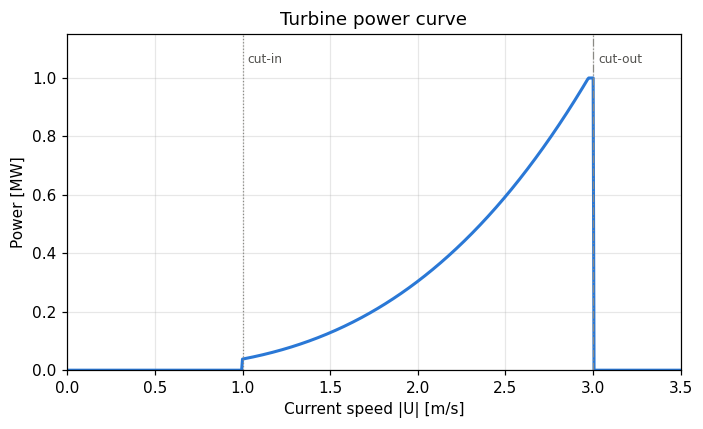

In [8]:
u_pc = np.linspace(0, 3.5, 701)
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(u_pc, turbine_power(u_pc) / 1e6, color=C_U, lw=2)
ax.axvline(U_CUT_IN, color=C_REF, lw=0.8, ls=":")
ax.axvline(U_CUT_OUT, color=C_REF, lw=0.8, ls="-.")
ax.text(U_CUT_IN + 0.03, 1.05, "cut-in", fontsize=8, color=C_ENV)
ax.text(U_CUT_OUT + 0.03, 1.05, "cut-out", fontsize=8, color=C_ENV)
ax.set_xlim(0, 3.5)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Current speed |U| [m/s]")
ax.set_ylabel("Power [MW]")
ax.set_title("Turbine power curve")
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/tidal_power_curve.png")
plt.show()

### Plot: generated power over 31 days (15 pts)

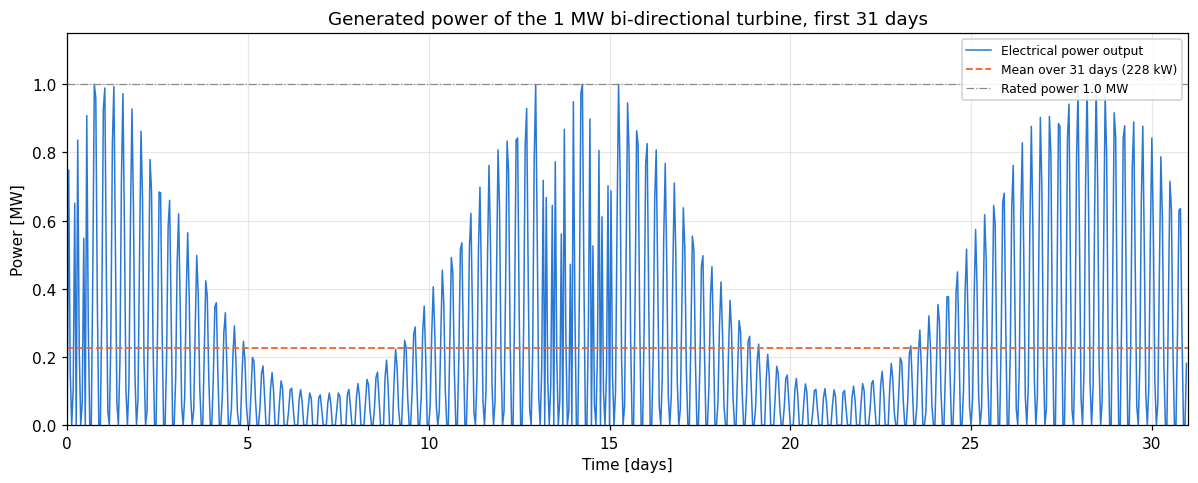

In [9]:
n31 = 31 * 24
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(t[:n31] / 24, P[:n31] / 1e6, color=C_U, lw=1.0, label="Electrical power output")
ax.axhline(P[:n31].mean() / 1e6, color=C_SP, lw=1.2, ls="--",
           label=f"Mean over 31 days ({P[:n31].mean() / 1e3:.0f} kW)")
ax.axhline(P_RATED / 1e6, color=C_REF, lw=0.8, ls="-.", label="Rated power 1.0 MW")
ax.set_xlim(0, 31)
ax.set_ylim(0, 1.15)
ax.set_xlabel("Time [days]")
ax.set_ylabel("Power [MW]")
ax.set_title("Generated power of the 1 MW bi-directional turbine, first 31 days")
ax.legend(loc="upper right", fontsize=8, framealpha=0.9)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/tidal_power_31days.png")
plt.show()

### Annual results

- Annual mean power: $\bar{P} = \frac{1}{N}\sum_i P_i$ (5 pts)
- Annual energy yield: $AEY = \sum_i P_i \, \Delta t$, with $\Delta t = 1$ h
- Capacity factor: $CF = \dfrac{AEY}{P_{rated} \cdot 8760\,\text{h}}$ (5 pts)

In [10]:
P_mean = P.mean()
P_max = P.max()
AEY = P.sum() * DT                         # Wh
CF = AEY / (P_RATED * N_HOURS * DT)

print(f"Annual mean power      : {P_mean / 1e3:.1f} kW")
print(f"Maximum power produced : {P_max / 1e3:.1f} kW")
print(f"AEY                    : {AEY / 1e6:.1f} MWh = {AEY / 1e9:.3f} GWh")
print(f"Capacity factor        : {CF:.3f} = {CF * 100:.1f} %")
print()
print(f"Hours generating       : {np.sum(P > 0)} h ({np.mean(P > 0) * 100:.1f} %)")
print(f"Hours below cut-in     : {np.sum(speed < U_CUT_IN)} h ({np.mean(speed < U_CUT_IN) * 100:.1f} %)")
print(f"Hours at rated power   : {np.sum(P >= P_RATED)} h")
print(f"Hours above cut-out    : {np.sum(speed > U_CUT_OUT)} h")

Annual mean power      : 199.4 kW
Maximum power produced : 1000.0 kW
AEY                    : 1746.3 MWh = 1.746 GWh
Capacity factor        : 0.199 = 19.9 %

Hours generating       : 6012 h (68.6 %)
Hours below cut-in     : 2701 h (30.8 %)
Hours at rated power   : 22 h
Hours above cut-out    : 47 h


---
## 1.4 Assumptions and discussion

- **Constituents:** Only M2, S2 and K2 are used ($F = 0$). Diurnal (K1, O1), shallow-water (M4) and long-period constituents are neglected. M2 ± S2 reproduces the tabulated spring (2.68 m/s) and neap (1.80 m/s) peak currents well.
- **Phases:** All phases are zero, so $t = 0$ is an equinoctial spring tide. This only shifts the series in time; the annual values do not depend on it.
- **K2 effect:** Because of the S2–K2 beat, the peak spring current varies over the year. At the strongest springs it reaches 3.10 m/s, which is above the 3.0 m/s cut-out, so the turbine stops for about 47 h per year.
- **Turbine:** Flood and ebb are treated as symmetric and the turbine as ideally bi-directional. Efficiency is fixed at 0.45 over the whole range, and availability is 100 % (no downtime). Turbulence, velocity shear over the rotor, and wake and blockage effects are ignored.
- **Time step:** Each hourly velocity is held constant over its hour when adding up energy, so short peaks between samples can be missed.
- **Result:** The CF of about 20 % is low. The site's mean speed (about 1.4 m/s) is well below the rated speed (2.97 m/s), and the current is below cut-in for about 31 % of the year (around slack water and during neaps). A lower rated speed, meaning a larger rotor or a lower rated power, would raise the CF.

---
# Part 2 – Operation of a Tidal Range Power Plant

This part simulates a **one-way ebb-generation lagoon** with the 0-D model from Appendix 2. The tidal elevation input is `data/Tidal_range_Dataset_2026.csv`, which covers one representative 14-day spring–neap cycle.

In [11]:
import pandas as pd
from matplotlib.patches import Patch
from scipy.integrate import quad

DATA_FILE = "data/Tidal_range_Dataset_2026.csv"

# Colours for Part 2
C_SEA, C_BASIN, C_HEAD = "#8a8984", "#2a78d6", "#eb6834"
C_HYD, C_EL = "#2a78d6", "#eb6834"
C_TXT = "#52514e"

## 2.1 Input data

| Parameter | Value |
|---|---|
| Wall length / nominal basin area | 9 km / ~10 km² |
| Turbines | $N = 10$ bulb turbines × 20 MWe = 200 MWe |
| Turbine diameter | $D = 8.0$ m |
| Turbine efficiency (fixed) | $\eta = 0.90$ |
| Turbine flow rate (constant, all heads) | $Q_t = 500$ m³/s per turbine |
| Sluice gate area | 500 m² |
| Discharge coefficient | $C_d = 1.0$ |
| Start / end generating head | $H_{se} = 3.0$ m, $H_{ee} = 1.0$ m |
| Annual scaling factor (14-day cycle → year) | 24.377 |

The basin area depends on the basin water level $Z$:

$$A(Z) = -264.55 Z^4 - 3835.98 Z^3 - 59920.6 Z^2 + 554761.9 Z + 1.1\times10^{7} \quad [\text{m}^2]$$

In [12]:
RHO = 1025.0        # kg/m3
G = 9.81            # m/s2

N_TURB = 10
P_UNIT_RATED = 20e6          # W (electrical, per turbine)
P_INSTALLED = N_TURB * P_UNIT_RATED
D_TURB = 8.0                 # m
ETA_T = 0.90
Q_TURB = 500.0               # m3/s per turbine
A_SLUICE = 500.0             # m2
CD = 1.0
H_SE = 3.0                   # m, start generating
H_EE = 1.0                   # m, end generating
A_NOMINAL = 10e6             # m2, "basin area of about 10 km2"
YEAR_FACTOR = 24.377         # 14-day cycles per year (given)

A_TURB_OPEN = N_TURB * np.pi * D_TURB**2 / 4    # turbine passage area
A_FILL = A_SLUICE + A_TURB_OPEN                 # sluices AND turbines open while filling


def basin_area(z):
    return (-264.55 * z**4 - 3835.98 * z**3 - 59920.6 * z**2
            + 554761.9 * z + 1.1e7)


print(f"Turbine opening area (10 x pi D^2/4) : {A_TURB_OPEN:.1f} m2")
print(f"Total filling area A_s               : {A_FILL:.1f} m2")
print(f"Basin area A(-5), A(0), A(+5)        : "
      f"{basin_area(-5) / 1e6:.2f}, {basin_area(0) / 1e6:.2f}, {basin_area(5) / 1e6:.2f} km2")

Turbine opening area (10 x pi D^2/4) : 502.7 m2
Total filling area A_s               : 1002.7 m2
Basin area A(-5), A(0), A(+5)        : 7.04, 11.00, 11.63 km2


### Tidal elevation data

In [13]:
df = pd.read_csv(DATA_FILE, encoding="utf-8-sig")
t_h = df["Total hour"].to_numpy()               # h
Y = df["Tidal range Y(t) (m)"].to_numpy()       # m about MSL
DT_H = t_h[1] - t_h[0]                          # h
DT_S = DT_H * 3600                                # s

print(f"{len(Y)} samples, dt = {DT_H:.1f} h, t = {t_h[0]} ... {t_h[-1]} h ({t_h[-1] / 24:.0f} days)")
print(f"Y min / max / mean = {Y.min():.2f} / {Y.max():.2f} / {Y.mean():.3f} m")

3360 samples, dt = 0.1 h, t = 0.1 ... 336.0 h (14 days)
Y min / max / mean = -4.99 / 4.99 / 0.007 m


---
## 2.2 Energy potential of the basin during a spring and a neap tide (10 pts)

From the lecture: the water trapped at high tide has mass $\rho A R$ and its centre of gravity is $R/2$ above low water. The maximum energy available per tide is therefore

$$E_{tide} = \rho A R \, g \, \frac{R}{2} = \frac{\rho g A R^2}{2} \quad \text{[J]}$$

Averaged over one semi-diurnal tidal cycle ($\tau \approx 12.42$ h), the mean power is

$$\bar{P}_{TC} = \frac{\rho g A R^2}{2\tau} \quad \text{[W]}$$

The spring range $R_s$ and neap range $R_n$ are taken from the dataset as the largest and smallest high-water to low-water difference. The nominal basin area $A = 10$ km² is used.

As a check, the same potential is also computed with the **variable basin area**. The water between low-water level $z_L$ and high-water level $z_H$ drops through a height $(z - z_L)$:

$$E_{tide} = \rho g \int_{z_L}^{z_H} A(z)\,(z - z_L)\,dz$$

In [14]:
# High and low waters in the dataset
is_hw = (Y[1:-1] > Y[:-2]) & (Y[1:-1] >= Y[2:])
is_lw = (Y[1:-1] < Y[:-2]) & (Y[1:-1] <= Y[2:])
i_hw = np.where(is_hw)[0] + 1
i_lw = np.where(is_lw)[0] + 1

# Range of every ebb: each HW with the next LW
ranges = []
for i in i_hw:
    nxt = i_lw[i_lw > i]
    if len(nxt):
        ranges.append((t_h[i], Y[i], Y[nxt[0]], Y[i] - Y[nxt[0]]))
ranges = np.array(ranges)

k_s, k_n = np.argmax(ranges[:, 3]), np.argmin(ranges[:, 3])
R_s, R_n = ranges[k_s, 3], ranges[k_n, 3]
TAU = 12.42 * 3600  # s


def e_tide_const(R, A=A_NOMINAL):
    return RHO * G * A * R**2 / 2


def e_tide_var(z_hi, z_lo):
    val, _ = quad(lambda z: basin_area(z) * (z - z_lo), z_lo, z_hi)
    return RHO * G * val


rows = []
for name, k in (("Spring", k_s), ("Neap", k_n)):
    t_hw, z_hi, z_lo, R = ranges[k]
    E_c = e_tide_const(R)
    E_v = e_tide_var(z_hi, z_lo)
    rows.append([name, t_hw, z_hi, z_lo, R, E_c / 3.6e12, E_c / TAU / 1e6, E_v / 3.6e12])

pot = pd.DataFrame(rows, columns=["Tide", "HW time [h]", "HW [m]", "LW [m]", "Range R [m]",
                                  "E_tide (A=10 km2) [GWh]", "Mean power per cycle [MW]",
                                  "E_tide (A(Z)) [GWh]"])
pot.round(3)

,Tide,HW time [h],HW [m],LW [m],Range R [m],E_tide (A=10 km2) [GWh],Mean power per cycle [MW],E_tide (A(Z)) [GWh]
0,Spring,12.3,4.975,-4.943,9.918,1.374,110.616,1.553
1,Neap,173.8,2.005,-2.004,4.008,0.224,18.066,0.253


In [15]:
E_s, E_n = e_tide_const(R_s), e_tide_const(R_n)
print(f"Spring tide: R_s = {R_s:.2f} m -> E = {E_s / 1e12:.2f} TJ = {E_s / 3.6e9:.0f} MWh per tide, "
      f"mean power over the cycle {E_s / TAU / 1e6:.0f} MW")
print(f"Neap tide  : R_n = {R_n:.2f} m -> E = {E_n / 1e12:.2f} TJ = {E_n / 3.6e9:.0f} MWh per tide, "
      f"mean power over the cycle {E_n / TAU / 1e6:.0f} MW")
print(f"Spring / neap energy ratio = (R_s/R_n)^2 = {E_s / E_n:.1f}")

Spring tide: R_s = 9.92 m -> E = 4.95 TJ = 1374 MWh per tide, mean power over the cycle 111 MW
Neap tide  : R_n = 4.01 m -> E = 0.81 TJ = 224 MWh per tide, mean power over the cycle 18 MW
Spring / neap energy ratio = (R_s/R_n)^2 = 6.1


The spring tide holds roughly six times the energy of a neap tide, because $E \propto R^2$. These values are an upper bound for one ebb. A one-way ebb scheme can only capture part of it: it cannot start until $H \ge 3$ m, it stops at $H = 1$ m, and the basin never fully drains to low water.

---
## 2.3 0-D model of the one-way ebb-generation scheme

**Head difference:** $H(t) = Z(t) - Y(t)$, where $Z$ is the basin level and $Y$ is the sea level. $H > 0$ means the basin is higher than the sea.

**Mass balance, discretised with the backward difference scheme** ($\Delta t = 0.1$ h):

$$Z_{i+1} = Z_i + \frac{Q_i}{A(Z_i)}\Delta t$$

**Operating modes (cycle 1 → 2 → 3 → 4 → 1):**

| Mode | Condition to enter | Flow $Q$ (+ into basin) | Power |
|---|---|---|---|
| 1. **Filling** (sluices + turbines open) | sea rises above basin, $H < 0$ | $Q_s = C_d A_s \sqrt{2g\lvert H\rvert}$ | 0 |
| 2. **Holding** (after high water) | sea falls below basin, $H \ge 0$ | 0 | 0 |
| 3. **Generating** | $H \ge H_{se} = 3$ m | $-N Q_t = -5000$ m³/s | $P = N\rho g H Q_t \eta$ |
| 4. **Holding** (after generation) | $H < H_{ee} = 1$ m | 0 | 0 |

$A_s$ is the total open area: sluices plus the 10 turbine passages ($10 \cdot \pi D^2/4$).

**Initial condition:** $Z_0 = Y_0$. The record starts at high water with the sea falling, so the model starts in mode 2 (holding).

**Implementation details:**
- Filling only lets water in. If the basin level catches up with a still-rising sea in one time step, the flow is set to zero for that step rather than letting water run back out.
- Mode 1 ends when the sea has started falling and has dropped to the basin level.

In [16]:
FILL, HOLD_HW, GEN, HOLD_LW = 1, 2, 3, 4
MODE_NAMES = {FILL: "Filling (sluicing)", HOLD_HW: "Holding (after HW)",
              GEN: "Generating (ebb)", HOLD_LW: "Holding (after generation)"}

n_r = len(Y)
Z = np.zeros(n_r)
H = np.zeros(n_r)
Q = np.zeros(n_r)           # total flow into basin [m3/s]
Q_sl = np.zeros(n_r)        # sluice + turbine-passage flow while filling [m3/s]
Q_tb = np.zeros(n_r)        # turbine flow while generating [m3/s]
P_hyd = np.zeros(n_r)       # hydraulic power at the turbines [W]
P_el = np.zeros(n_r)        # power produced [W]
mode = np.zeros(n_r, dtype=int)

Z[0] = Y[0]
m = HOLD_HW

for i in range(n_r):
    H[i] = Z[i] - Y[i]
    sea_falling = i > 0 and Y[i] < Y[i - 1]

    # --- mode switching ---
    if m == FILL and H[i] >= 0 and sea_falling:
        m = HOLD_HW
    elif m == HOLD_HW and H[i] >= H_SE:
        m = GEN
    elif m == GEN and H[i] < H_EE:
        m = HOLD_LW
    elif m == HOLD_LW and H[i] < 0:
        m = FILL
    mode[i] = m

    # --- flows and power ---
    if m == FILL and H[i] < 0:
        Q_sl[i] = CD * A_FILL * np.sqrt(2 * G * -H[i])
    elif m == GEN:
        Q_tb[i] = N_TURB * Q_TURB
        P_hyd[i] = RHO * G * H[i] * Q_tb[i]
        P_el[i] = ETA_T * P_hyd[i]
    Q[i] = Q_sl[i] - Q_tb[i]

    # --- backward difference update ---
    if i < n_r - 1:
        Z[i + 1] = Z[i] + Q[i] / basin_area(Z[i]) * DT_S

print("Time share per mode over 14 days:")
for k, name in MODE_NAMES.items():
    print(f"  {name:<28}: {np.mean(mode == k) * 100:5.1f} %")
print(f"\nNumber of generating periods: {np.sum(np.diff((mode == GEN).astype(int)) == 1)}")
print(f"Max head during generation   : {H[mode == GEN].max():.2f} m")
print(f"Max power produced           : {P_el.max() / 1e6:.1f} MW")

Time share per mode over 14 days:
  Filling (sluicing)          :  39.7 %
  Holding (after HW)          :  21.0 %
  Generating (ebb)            :  29.3 %
  Holding (after generation)  :  10.0 %

Number of generating periods: 27
Max head during generation   : 5.06 m
Max power produced           : 229.2 MW


---
## 2.4 Basin level and head difference over the 14-day cycle (10 pts)

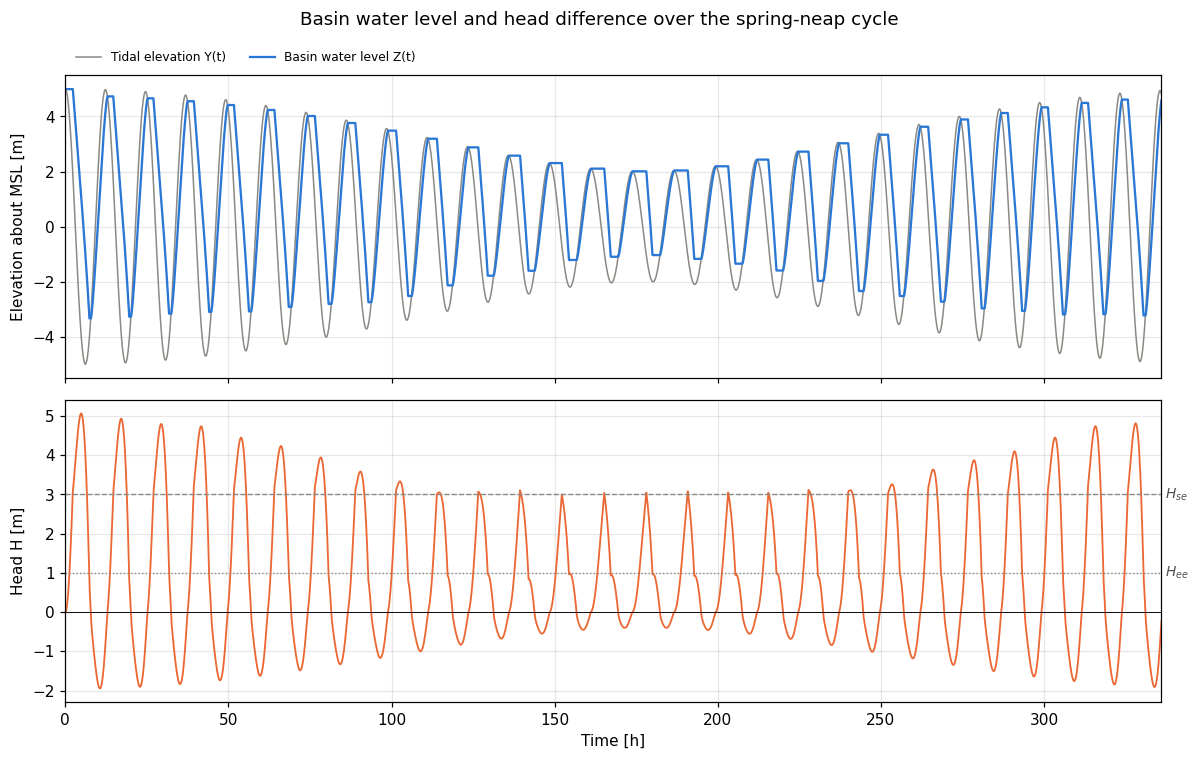

In [17]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

ax1.plot(t_h, Y, color=C_SEA, lw=1.0, label="Tidal elevation Y(t)")
ax1.plot(t_h, Z, color=C_BASIN, lw=1.5, label="Basin water level Z(t)")
ax1.set_ylabel("Elevation about MSL [m]")
fig.suptitle("Basin water level and head difference over the spring-neap cycle")
ax1.legend(loc="lower left", bbox_to_anchor=(0, 1.0), ncol=2, fontsize=8, frameon=False)

ax2.plot(t_h, H, color=C_HEAD, lw=1.2, label="Head difference H = Z - Y")
ax2.axhline(H_SE, color=C_REF, ls="--", lw=0.9)
ax2.axhline(H_EE, color=C_REF, ls=":", lw=0.9)
ax2.axhline(0, color="black", lw=0.6)
ax2.text(337, H_SE, "$H_{se}$", va="center", fontsize=9, color=C_TXT)
ax2.text(337, H_EE, "$H_{ee}$", va="center", fontsize=9, color=C_TXT)
ax2.set_xlabel("Time [h]")
ax2.set_ylabel("Head H [m]")
ax2.set_xlim(0, t_h[-1])


fig.tight_layout()
fig.savefig(f"{OUT_DIR}/range_levels_head_14days.png")
plt.show()

The basin follows the sea up during filling and is held near high water. It only drops while the turbines run. During neap tides, the sea falls less far below the held basin level, so the head barely exceeds $H_{se}$ and the generating periods are shorter.

---
## 2.5 Tidal elevation and basin level for the first 50 hours, with operating modes (10 pts)

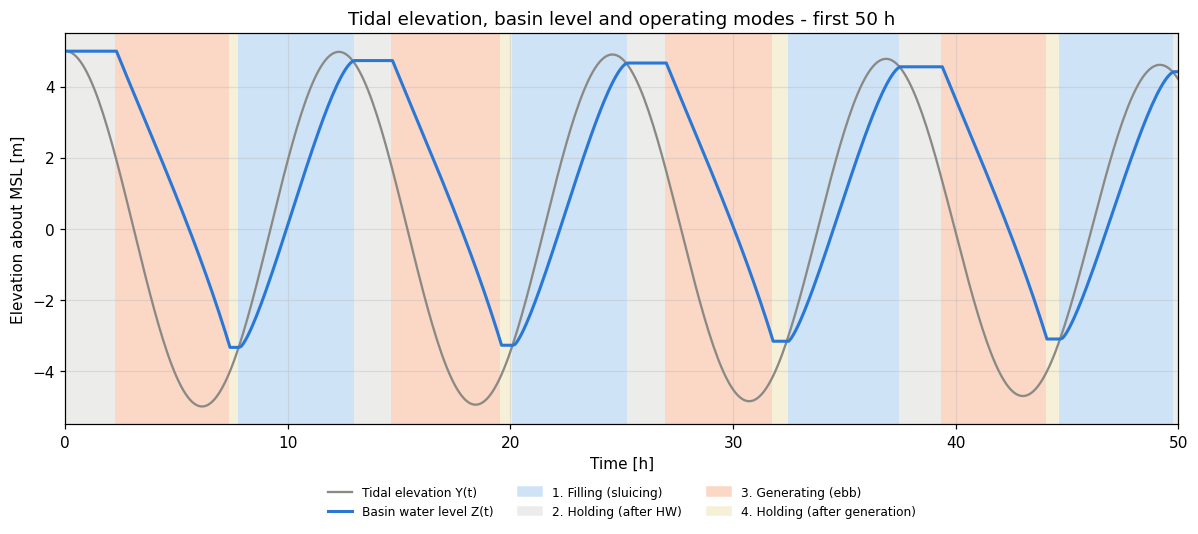

In [18]:
MODE_COLORS = {FILL: "#cfe3f7", HOLD_HW: "#ececea", GEN: "#fbd7c6", HOLD_LW: "#f6f0d8"}
T50 = 50.0
w = t_h <= T50


def shade_modes(ax):
    # Background band for every run of constant mode inside the 50 h window
    idx = np.where(w)[0]
    start = idx[0]
    for j in range(idx[0] + 1, idx[-1] + 2):
        if j > idx[-1] or mode[j] != mode[start]:
            ax.axvspan(t_h[start] - DT_H / 2, t_h[min(j, idx[-1])] - DT_H / 2 if j <= idx[-1] else T50,
                       color=MODE_COLORS[mode[start]], lw=0, zorder=0)
            start = j


mode_legend = [Patch(color=MODE_COLORS[k], label=f"{k}. {MODE_NAMES[k]}") for k in MODE_NAMES]

fig, ax = plt.subplots(figsize=(11, 5))
shade_modes(ax)
l1, = ax.plot(t_h[w], Y[w], color=C_SEA, lw=1.5, label="Tidal elevation Y(t)")
l2, = ax.plot(t_h[w], Z[w], color=C_BASIN, lw=2, label="Basin water level Z(t)")
ax.set_xlim(0, T50)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Elevation about MSL [m]")
ax.set_title("Tidal elevation, basin level and operating modes - first 50 h")
ax.legend(handles=[l1, l2] + mode_legend, loc="upper center", bbox_to_anchor=(0.5, -0.13),
          ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/range_levels_modes_50h.png")
plt.show()

---
## 2.6 Hydraulic power and power produced, first 50 hours (10 pts)

- Hydraulic power at the turbines: $P_{hyd} = N \rho g H Q_t$
- Power produced: $P = \eta P_{hyd}$

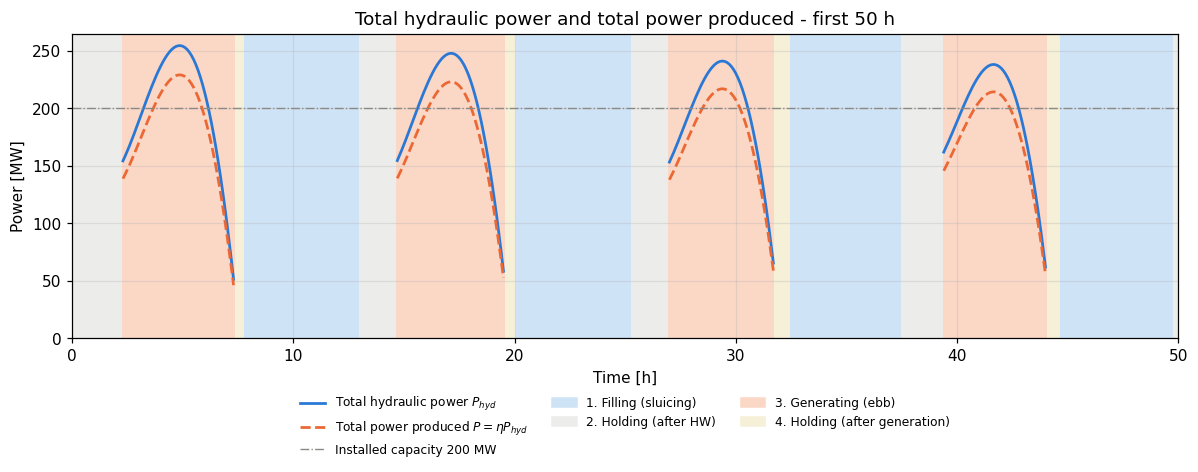

In [19]:
fig, ax = plt.subplots(figsize=(11, 4.5))
shade_modes(ax)
p_h = np.where(mode == GEN, P_hyd, np.nan)
p_e = np.where(mode == GEN, P_el, np.nan)
ax.plot(t_h[w], p_h[w] / 1e6, color=C_HYD, lw=1.8, label="Total hydraulic power $P_{hyd}$")
ax.plot(t_h[w], p_e[w] / 1e6, color=C_EL, lw=1.8, ls="--", label="Total power produced $P = \\eta P_{hyd}$")
ax.axhline(P_INSTALLED / 1e6, color=C_REF, ls="-.", lw=0.9, label="Installed capacity 200 MW")
ax.set_xlim(0, T50)
ax.set_ylim(bottom=0)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Power [MW]")
ax.set_title("Total hydraulic power and total power produced - first 50 h")
ax.legend(handles=ax.get_legend_handles_labels()[0] + mode_legend, loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/range_power_50h.png")
plt.show()

---
## 2.7 Flow rates, first 50 hours (10 pts)

Sign convention: positive flow goes **into** the basin (filling through sluices and turbine passages). Negative flow goes **out** through the turbines while generating.

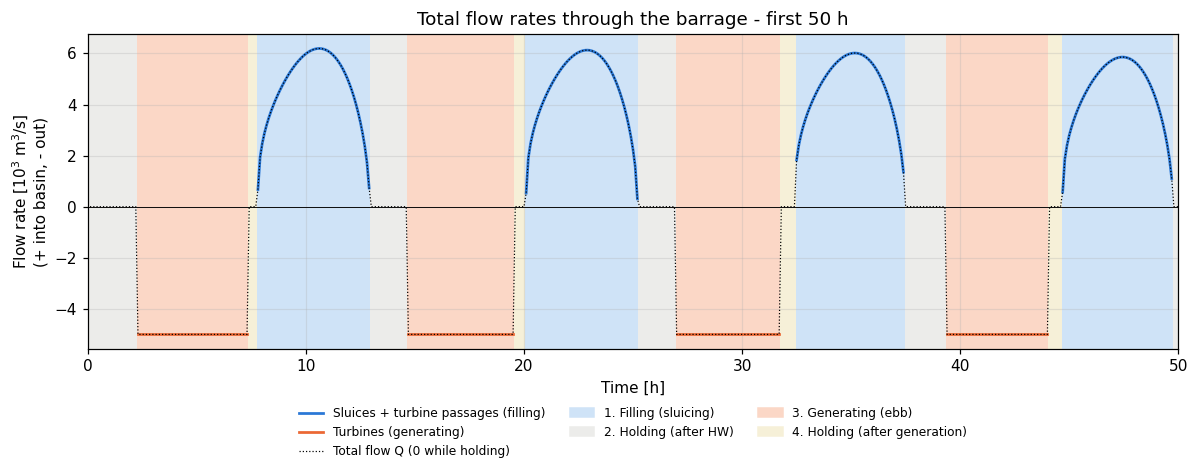

Peak filling flow  : 6195 m3/s
Turbine flow (gen) : 5000 m3/s


In [20]:
fig, ax = plt.subplots(figsize=(11, 4.5))
shade_modes(ax)
q_fill = np.where(mode == FILL, Q_sl, np.nan)
q_gen = np.where(mode == GEN, -Q_tb, np.nan)
ax.plot(t_h[w], q_fill[w] / 1e3, color=C_BASIN, lw=1.8, label="Sluices + turbine passages (filling)")
ax.plot(t_h[w], q_gen[w] / 1e3, color=C_EL, lw=1.8, label="Turbines (generating)")
ax.plot(t_h[w], Q[w] / 1e3, color="black", lw=0.8, ls=":", label="Total flow Q (0 while holding)")
ax.axhline(0, color="black", lw=0.6)
ax.set_xlim(0, T50)
ax.set_xlabel("Time [h]")
ax.set_ylabel("Flow rate [10$^3$ m$^3$/s]\n(+ into basin, - out)")
ax.set_title("Total flow rates through the barrage - first 50 h")
ax.legend(handles=ax.get_legend_handles_labels()[0] + mode_legend, loc="upper center",
          bbox_to_anchor=(0.5, -0.15), ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/range_flow_50h.png")
plt.show()

print(f"Peak filling flow  : {Q_sl.max():.0f} m3/s")
print(f"Turbine flow (gen) : {N_TURB * Q_TURB:.0f} m3/s")

---
## 2.8 Annual energy yield and capacity factor (5 pts)

$$E_{14d} = \sum_i P_i\,\Delta t, \qquad AEY = 24.377 \cdot E_{14d}, \qquad CF = \frac{AEY}{P_{installed}\cdot 8760\,\text{h}}$$

In [21]:
E_14d = P_el.sum() * DT_S          # J
AEY_R = YEAR_FACTOR * E_14d        # J
CF_R = AEY_R / (P_INSTALLED * 8760 * 3600)

# Energy per individual ebb generation period
starts = np.where(np.diff((mode == GEN).astype(int)) == 1)[0] + 1
ends = np.where(np.diff((mode == GEN).astype(int)) == -1)[0] + 1
per_ebb = [P_el[s:e].sum() * DT_S / 3.6e9 for s, e in zip(starts, ends)]

print(f"Energy over the 14-day cycle : {E_14d / 3.6e12:.2f} GWh")
print(f"Energy per ebb (spring)      : {max(per_ebb):.0f} MWh   (potential {E_s / 3.6e9:.0f} MWh)")
print(f"Energy per ebb (neap)        : {min(per_ebb):.0f} MWh   (potential {E_n / 3.6e9:.0f} MWh)")
print(f"Mean power over the cycle    : {P_el.mean() / 1e6:.1f} MW")
print()
print(f"AEY = {YEAR_FACTOR} x E_14d      : {AEY_R / 3.6e12:.1f} GWh/yr")
print(f"Capacity factor              : {CF_R:.3f} = {CF_R * 100:.1f} %")

Energy over the 14-day cycle : 14.23 GWh
Energy per ebb (spring)      : 916 MWh   (potential 1374 MWh)
Energy per ebb (neap)        : 190 MWh   (potential 224 MWh)
Mean power over the cycle    : 42.4 MW

AEY = 24.377 x E_14d      : 346.9 GWh/yr
Capacity factor              : 0.198 = 19.8 %


### Sensitivity check: turbine rating

The 0-D model uses a constant $Q_t$ and a fixed $\eta$ at all heads, so the power per turbine is not limited to the 20 MWe rating. At high spring heads the model gives more than 20 MW per turbine. The cell below repeats the energy calculation with the output capped at 200 MW, to show how large this effect is. The water levels do not change, because $Q_t$ stays constant.

In [22]:
P_cap = np.minimum(P_el, P_INSTALLED)
AEY_cap = YEAR_FACTOR * P_cap.sum() * DT_S
CF_cap = AEY_cap / (P_INSTALLED * 8760 * 3600)
print(f"Time above 200 MW during generation : {np.mean(P_el[mode == GEN] > P_INSTALLED) * 100:.1f} % of generating time")
print(f"AEY (capped at 200 MW)               : {AEY_cap / 3.6e12:.1f} GWh/yr  ({(1 - AEY_cap / AEY_R) * 100:.1f} % lower)")
print(f"CF  (capped at 200 MW)               : {CF_cap * 100:.1f} %")

Time above 200 MW during generation : 12.2 % of generating time
AEY (capped at 200 MW)               : 343.4 GWh/yr  (1.0 % lower)
CF  (capped at 200 MW)               : 19.6 %


---
## 2.9 Summary

| Quantity | Value |
|---|---|
| Spring / neap tidal range | 9.92 m / 4.01 m |
| Energy potential per tide, spring / neap ($A$ = 10 km²) | 1374 MWh / 224 MWh |
| Energy produced per ebb, spring / neap | 916 MWh / 190 MWh |
| Energy over the 14-day cycle | 14.2 GWh |
| Max head / max power during generation | 5.1 m / 229 MW |
| **AEY** | **≈ 347 GWh/yr** |
| **CF** | **≈ 19.8 %** |

## 2.10 Assumptions and discussion

- **0-D model:** The basin has one uniform, horizontal water level. The sea level next to the barrage equals the tidal elevation, and building the lagoon is assumed not to change the tide outside it. Filling is the only mode that uses the orifice equation, with $C_d = 1$.
- **Turbines:** $Q_t = 500$ m³/s and $\eta = 0.9$ are fixed at every head. Real bulb turbines have a hill chart: the flow and efficiency drop at low head and the power is capped at rating. Using fixed values overestimates output at the ends of the head range and can exceed the 20 MWe rating at high heads (see the sensitivity check).
- **Operation:** Changes between modes are instantaneous. The turbines do not pump, and there is no flood generation. Generation always starts at $H_{se} = 3$ m and stops at $H_{ee} = 1$ m. An optimised schedule would adjust these heads depending on the tide.
- **Energy potential vs yield:** The yield per ebb is only a fraction of the theoretical $\rho g A R^2/2$. The basin is never emptied to low water, the turbines do not run below 1 m of head, and one-way ebb operation discards the flood half of the cycle.
- **Neap tides:** With a neap range of about 4 m and $H_{se} = 3$ m, only a short window with small heads is available, so neap tides add little to the yield.
- **Annual scaling:** The 14-day record is assumed to represent the whole year (factor 24.377). Seasonal and equinoctial variations and the 18.6-year nodal cycle are ignored, and availability is 100 %.